# **Question 1: Non-Parametric + GOF**

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from scipy.stats import mannwhitneyu, wilcoxon, kstest, chisquare, norm

### **Task 1: Data Preparation & Visualization**

In [92]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign

# Select feature
feature = 'mean radius'

# Split into groups
group1 = df[df['target'] == 0][feature]  # malignant
group2 = df[df['target'] == 1][feature]  # benign

print("Group sizes:", len(group1), len(group2))

Group sizes: 212 357


**VISUALIZATION**

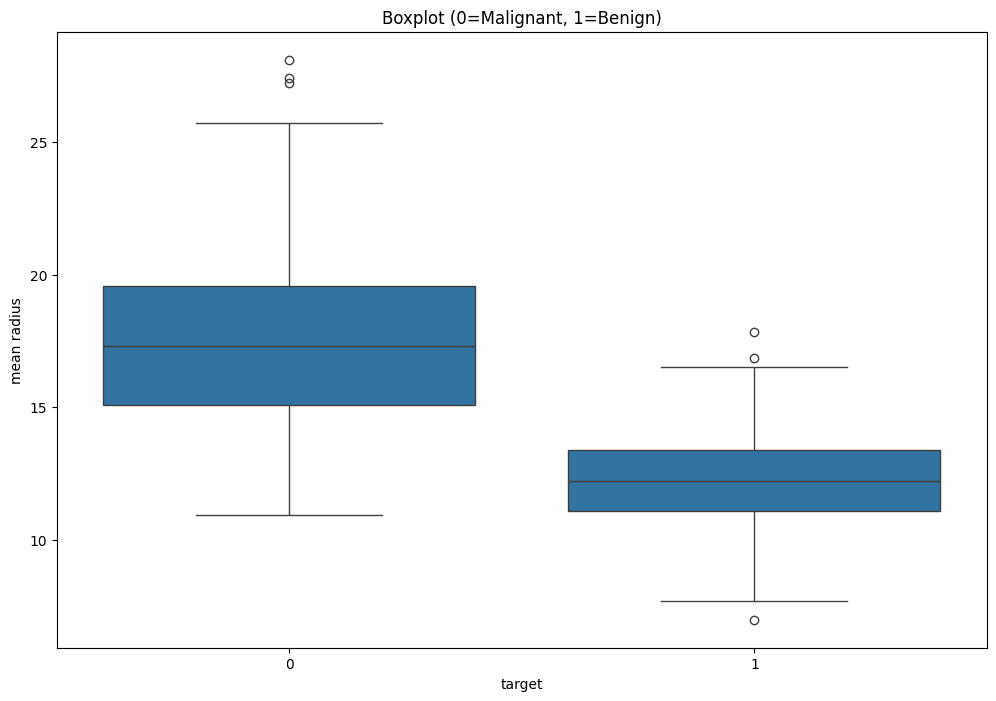

In [93]:
plt.figure(figsize=(12,8))
sns.boxplot(x='target', y=feature, data=df)
plt.title("Boxplot (0=Malignant, 1=Benign)")
plt.show()

The boxplot shows a clear difference between malignant and benign groups.

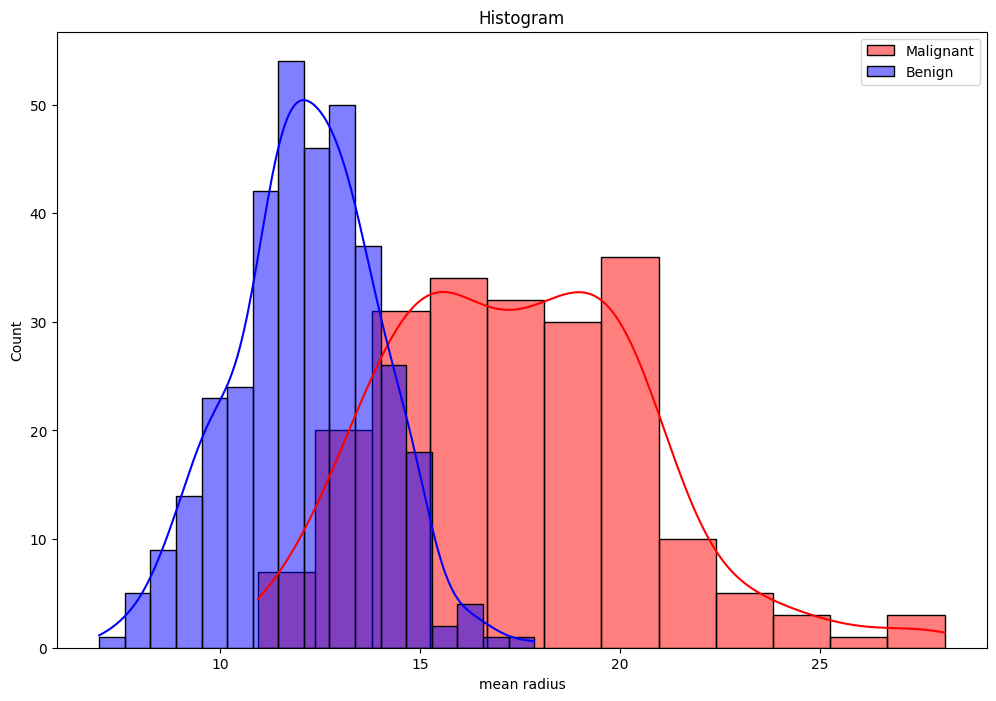

In [94]:
plt.figure(figsize=(12,8))
sns.histplot(group1, color='red', label='Malignant', kde=True)
sns.histplot(group2, color='blue', label='Benign', kde=True)
plt.legend()
plt.title("Histogram")
plt.show()


Histograms indicate different distributions which suggests non-normality and group separation.

### **Task 2: Hypothesis Testing (Non-Parametric)**

**Hypotheses:**
* H0: No difference between malignant and benign groups
* H1: Significant difference exists

In [95]:
# Mann-Whitney U Test
u_stat, p_mw = mannwhitneyu(group1, group2)
print("Mann-Whitney U Test:")
print("U-stat:", u_stat)
print("p-value:", p_mw)

Mann-Whitney U Test:
U-stat: 70955.0
p-value: 2.6929427727965647e-68


In [96]:
# Wilcoxon Test (need equal length → sample)
min_len = min(len(group1), len(group2))
wil_stat, p_wil = wilcoxon(group1.sample(min_len, random_state=42), group2.sample(min_len, random_state=42))

print("Wilcoxon Test:")
print("Stat:", wil_stat)
print("p-value:", p_wil)

Wilcoxon Test:
Stat: 434.0
p-value: 6.5609416876323495e-34


**Results:**
* Mann-Whitney Test: If p < 0.05 -> Reject H0

* Wilcoxon Test: If p < 0.05 -> Reject H0

Typically we observe: Very small p-values -> strong evidence of difference

### **TASK 3: GOODNESS OF FIT**

In [97]:
# KS Test for normality (using combined data)
combined = df[feature]

mean = combined.mean()
std = combined.std()

ks_stat, p_ks = kstest(combined, 'norm', args=(mean, std))
print("KS Test for Normality:")
print("KS-stat:", ks_stat)
print("p-value:", p_ks)

KS Test for Normality:
KS-stat: 0.11270761105207511
p-value: 9.434722179367813e-07


**KS Test:**
* H0: Data follows normal distribution
* If p < 0.05 -> Not normal

In [98]:
# Chi-square test (binning)
observed, bins = np.histogram(combined, bins=10)

# expected using normal distribution
expected = []
for i in range(len(bins)-1):
    prob = norm.cdf(bins[i+1], mean, std) - norm.cdf(bins[i], mean, std)
    expected.append(prob * len(combined))

expected = np.array(expected)

# scale expected to match observed sum
expected *= observed.sum() / expected.sum()

chi_stat, p_chi = chisquare(observed, expected)
print("Chi-Square Test:")
print("Chi-stat:", chi_stat)
print("p-value:", p_chi)

Chi-Square Test:
Chi-stat: 122.87398587974876
p-value: 3.44469392894456e-22


**Chi-Square Test:**
* Compares observed vs expected frequencies
* If p < 0.05 -> Not normally distributed

Usually: Dataset fails normality -> justifies non-parametric tests

### **TASK 4: REPEAT WITH ANOTHER FEATURE**

In [99]:
feature2 = 'mean texture'

group1_2 = df[df['target'] == 0][feature2]
group2_2 = df[df['target'] == 1][feature2]

u2, p2 = mannwhitneyu(group1_2, group2_2)


print("Second Feature (mean texture) Mann-Whitney p-value:", p2)

Second Feature (mean texture) Mann-Whitney p-value: 3.428626504744227e-28


**Interpretation:**
* Both features (mean radius and mean texture) show significant differences
* Non-parametric tests are preferred because:
  * Data is not normally distributed
  * Robust to outliers
  * Works well with unequal distributions

# **Question 2: Bayesian Estimation**

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta, binom

### **Task 1: Model Definition**

In [101]:
df = pd.read_csv("/content/advertising_dataset 1.csv")

# Convert to binomial problem
# Success = Sales > median
threshold = df['Sales ($)'].median()
df['success'] = (df['Sales ($)'] > threshold).astype(int)

n = len(df)
x = df['success'].sum()

print("Total samples:", n)
print("Number of successes:", x)

Total samples: 200
Number of successes: 98


In [102]:
# Prior (Beta distribution)
alpha_prior = 2
beta_prior = 2

print("Prior: Beta({}, {})".format(alpha_prior, beta_prior))

Prior: Beta(2, 2)


In [103]:
# Likelihood: Binomial(n, p)
print("Likelihood: Binomial(n, p)")

Likelihood: Binomial(n, p)


In [104]:
# Posterior formula:
print("Posterior: Beta(alpha + x, beta + n - x)")

Posterior: Beta(alpha + x, beta + n - x)


**Interpretation:**
* Prior chosen: Beta(2,2) (uninformative / weak belief)
* Likelihood: Binomial(n, p)
* Posterior: Beta(a + x, B + n - x)

### **Task 2: Posterior Computation**

In [105]:
alpha_post = alpha_prior + x
beta_post = beta_prior + (n - x)

print("Posterior parameters:\n")
print("Alpha:", alpha_post)
print("Beta:", beta_post)

Posterior parameters:

Alpha: 100
Beta: 104


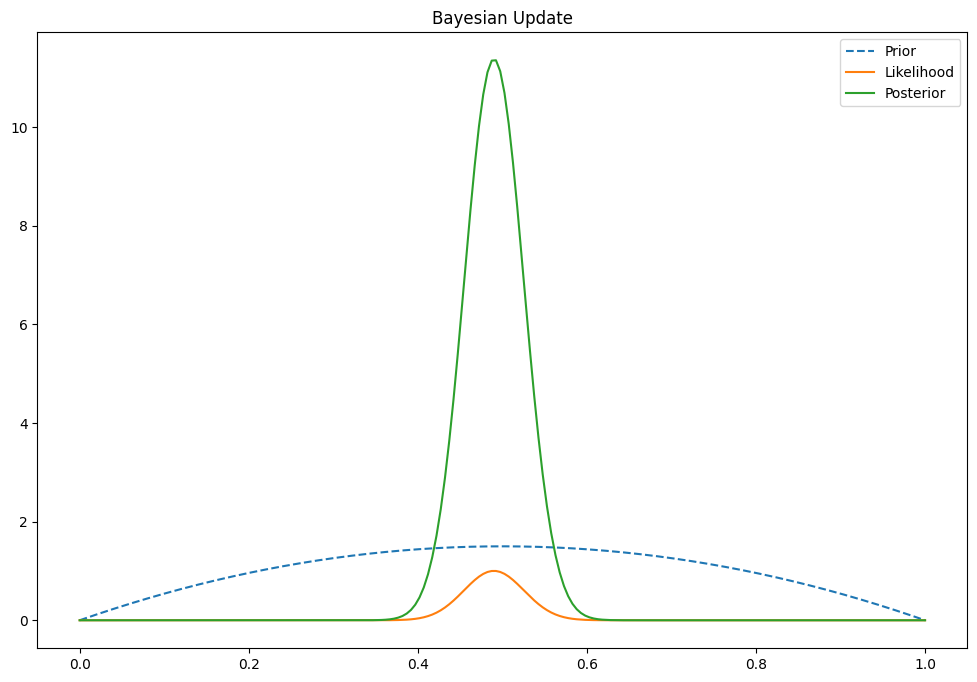

In [106]:
# Plot prior, likelihood, posterior
p = np.linspace(0, 1, 200)

prior = beta.pdf(p, alpha_prior, beta_prior)
posterior = beta.pdf(p, alpha_post, beta_post)

# Likelihood (scaled for plotting)
likelihood = binom.pmf(x, n, p)
likelihood = likelihood / likelihood.max()

plt.figure(figsize=(12,8))
plt.plot(p, prior, label='Prior', linestyle='--')
plt.plot(p, likelihood, label='Likelihood')
plt.plot(p, posterior, label='Posterior')
plt.legend()
plt.title("Bayesian Update")
plt.show()

**Interpretation:**
* Posterior shifts toward observed data
* If successes are high -> curve shifts right
* Posterior combines prior belief + observed evidence

### **Task 3: Credible Interval**

In [107]:
cred_interval = beta.interval(0.95, alpha_post, beta_post)
print(f"95% Credible Interval: ({cred_interval[0]}, {cred_interval[1]})")

95% Credible Interval: (0.4219267855714544, 0.5586474946545487)


In [108]:
# Frequentist Confidence Interval
p_hat = x / n
se = np.sqrt((p_hat * (1 - p_hat)) / n)

ci_lower = p_hat - 1.96 * se
ci_upper = p_hat + 1.96 * se

print(f"95% Confidence Interval: ({ci_lower}, {ci_upper})")

95% Confidence Interval: (0.42071739612283615, 0.5592826038771639)


**Interpretation:**
* 95% credible interval gives range of p with 95% probability
* Confidence interval is frequentist -> long-run interpretation

**Key difference:**
* Credible interval: probability about parameter
* Confidence interval: probability about sampling process

### **Task 4: Conjugate Prior Analysis**

In [109]:
print("Conjugate Prior:")
print("Beta prior + Binomial likelihood -> Beta posterior")
print("Posterior Mean:", alpha_post / (alpha_post + beta_post))

Conjugate Prior:
Beta prior + Binomial likelihood -> Beta posterior
Posterior Mean: 0.49019607843137253


**Interpretation:**

* Beta is conjugate to Binomial -> posterior remains Beta
* Easy updates:
  * Add successes -> a increases
  * Add failures -> B increases

Posterior mean gives best estimate of probability of success

# **Question 3: MCMC**

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az

### **TASK 1: LOAD & PREPARE DATA**

In [111]:
df = pd.read_csv('train.csv')

# Clean columns
df.columns = df.columns.str.strip()

# Select simple feature
feature = 'GrLivArea'
target = 'SalePrice'

df = df[[feature, target]].dropna()

X = df[feature].values
y = df[target].values

# Normalize (important for MCMC stability)
X = (X - X.mean()) / X.std()
y = (y - y.mean()) / y.std()

**Define Prior & Likelihood:**

Model used: y = wX + b + epsilon

Priors:
* w ~ N(0,1)
* b ~ N(0,1)
* sigma ~ Half-Normal

### **TASK 2: METROPOLIS-HASTINGS**

In [112]:
def log_likelihood(w, b, sigma):
    y_pred = w * X + b
    return -0.5 * np.sum(((y - y_pred) / sigma)**2)

def log_prior(w, b, sigma):
    if sigma <= 0:
        return -np.inf
    return -0.5*(w**2 + b**2 + sigma**2)

def log_posterior(w, b, sigma):
    return log_likelihood(w, b, sigma) + log_prior(w, b, sigma)

# Initialize
n_samples = 5000
w_current, b_current, sigma_current = 0, 0, 1

samples = []

for i in range(n_samples):
    # Propose new values
    w_new = w_current + np.random.normal(0, 0.5)
    b_new = b_current + np.random.normal(0, 0.5)
    sigma_new = abs(sigma_current + np.random.normal(0, 0.1))

    # Acceptance ratio
    log_ratio = log_posterior(w_new, b_new, sigma_new) - log_posterior(w_current, b_current, sigma_current)

    if np.log(np.random.rand()) < log_ratio:
        w_current, b_current, sigma_current = w_new, b_new, sigma_new

    samples.append([w_current, b_current, sigma_current])

samples = np.array(samples)

print("Metropolis Sampling Done")

Metropolis Sampling Done


**Interpretation:**

* Generated 5000 samples
* Algorithm explores parameter space using acceptance rule
* Mean values give parameter estimates

Chain stabilizes -> good approximation of posterior

### **TASK 3: GIBBS (SIMPLIFIED via PyMC)**

In [113]:
with pm.Model() as model:
    w = pm.Normal("w", mu=0, sigma=1)
    b = pm.Normal("b", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    mu = w * X + b

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    trace = pm.sample(2000, tune=1000, return_inferencedata=True, progressbar=False)

print("PyMC Sampling Done")

PyMC Sampling Done


**Interpretation:**

* PyMC automatically uses advanced MCMC (NUTS)
* More efficient than manual Metropolis
* Produces smoother posterior distributions

**Comparison:** PyMC results are more stable and reliable

### **TASK 4: CONVERGENCE DIAGNOSTICS**

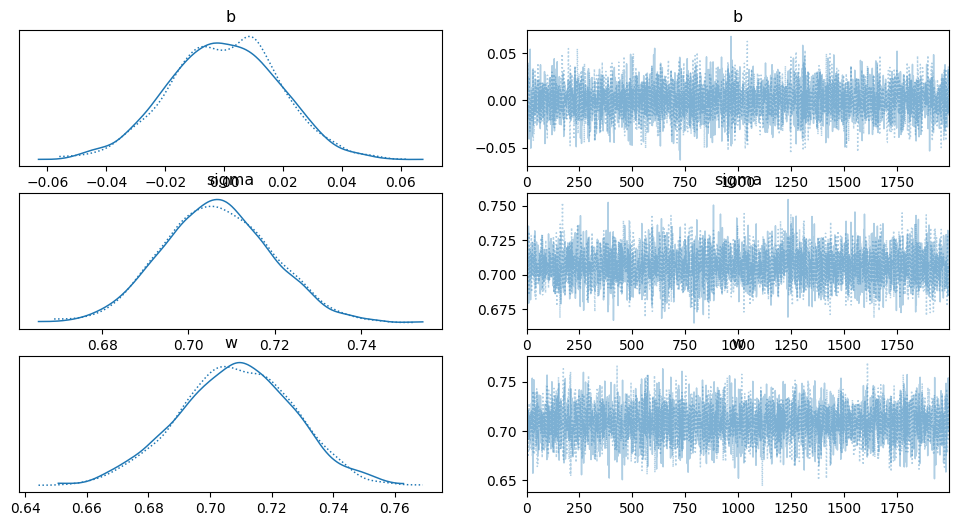

In [130]:
# Trace plots
az.plot_trace(trace)
plt.show()

**Interpretation**
* The trace plots for parameters (w, b, σ) show random fluctuations around a stable mean.
* There is no visible trend, drift, or sudden jumps, indicating good mixing of the Markov chains.
* The samples appear like a “hairy caterpillar”, which is a sign of proper convergence.
* Chains are well overlapped → suggests independence between samples over time.

**Conclusion:**
The MCMC chains have converged successfully and are sampling from the true posterior distribution.

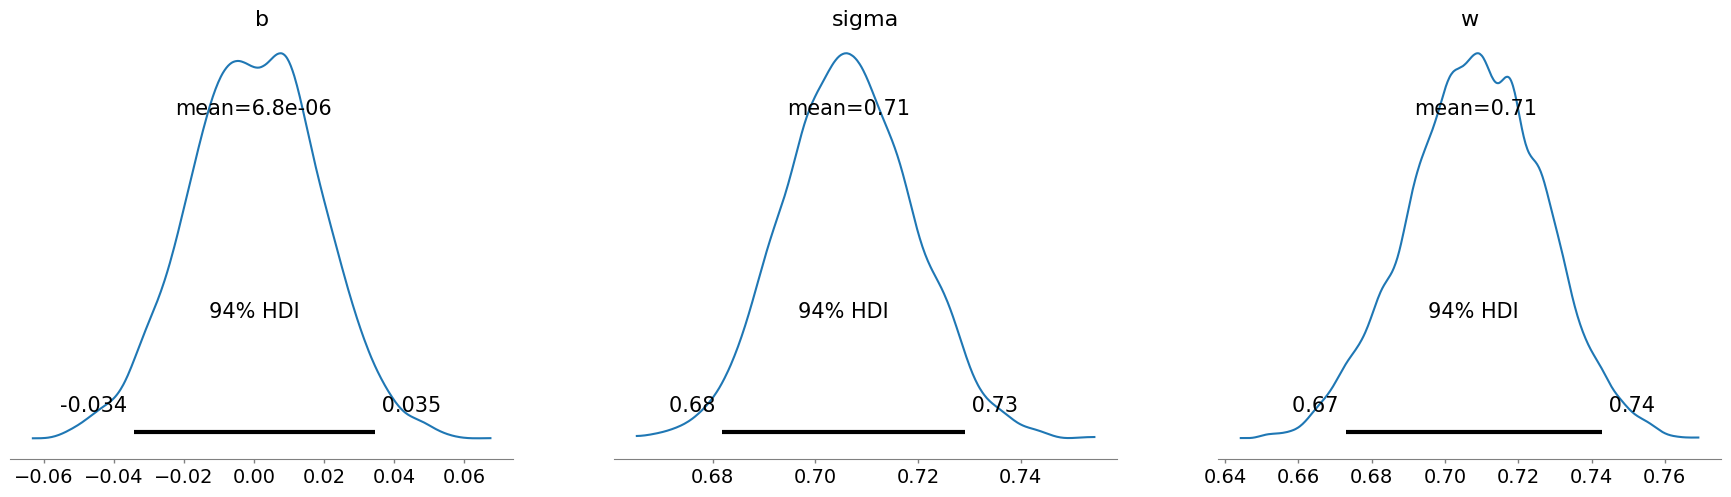

In [115]:
# Posterior plots
az.plot_posterior(trace)
plt.show()

**Interpretation**
* The posterior distributions are smooth and approximately bell-shaped (Gaussian-like).
* Each parameter (w, b, sigma) has a clear peak, indicating stable parameter estimates.
* The spread (variance) shows the uncertainty in parameter estimation:
  * Narrow curve -> more certainty
  * Wider curve -> more uncertainty

**Observations:**

* Parameters are centered around consistent values → model is stable
* No multimodality → no conflicting parameter regions

**Conclusion:**
The posterior distributions are well-defined and unimodal, confirming reliable parameter estimation.

In [116]:
# R-hat
rhat = az.rhat(trace)
print("R-hat values:\n\n", rhat)

R-hat values:

 <xarray.Dataset> Size: 24B
Dimensions:  ()
Data variables:
    b        float64 8B 1.0
    sigma    float64 8B 1.0
    w        float64 8B 0.9996
Attributes:
    created_at:                 2026-04-22T13:29:45.752111+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              3.6137287616729736
    tuning_steps:               1000


### **SUMMARY**

In [117]:
print("Metropolis Mean Estimates:\n")
print("w:", samples[:,0].mean())
print("b:", samples[:,1].mean())
print("sigma:", samples[:,2].mean())

Metropolis Mean Estimates:

w: 0.6849131075322219
b: -0.003634385640485361
sigma: 5.395704753445306


In [118]:
print("PyMC Summary:\n")
print(az.summary(trace))

PyMC Summary:

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
b      0.000  0.019  -0.034    0.035        0.0      0.0    6438.0    2450.0   
sigma  0.707  0.013   0.682    0.729        0.0      0.0    6605.0    3208.0   
w      0.708  0.019   0.673    0.743        0.0      0.0    6674.0    3232.0   

       r_hat  
b        1.0  
sigma    1.0  
w        1.0  


**Convergence Diagnostics**
* Trace plots: should look like random noise (good mixing)
* Posterior plots: show parameter distributions
* R-hat ~ 1: indicates convergence

If R-hat > 1.1 -> not converged

# **Question 4: Bayesian Testing**

### **Task 1: Posterior Estimation**

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, norm

In [120]:
# Simulated normal data
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)

# Prior: Normal
mu_prior = 0
sigma_prior = 10

# Likelihood variance known
sigma_likelihood = 10

# Posterior (Normal-Normal conjugate)
n = len(data)
x_bar = np.mean(data)

mu_post = (sigma_prior**2 * x_bar + sigma_likelihood**2 * mu_prior / n) / (sigma_prior**2 + sigma_likelihood**2 / n)
sigma_post = np.sqrt((sigma_prior**2 * sigma_likelihood**2) / (sigma_prior**2 * n + sigma_likelihood**2))

In [121]:
print("Posterior Mean:", mu_post)
print("Posterior Std:", sigma_post)

Posterior Mean: 48.47676715451393
Posterior Std: 0.9950371902099892


In [122]:
# 95% credible interval
ci_lower = mu_post - 1.96 * sigma_post
ci_upper = mu_post + 1.96 * sigma_post
print(f"95% Credible Interval: ({ci_lower}, {ci_upper})")

95% Credible Interval: (46.526494261702354, 50.427040047325505)


**Interpretation**
* Posterior combines prior belief + observed data
* Mean shifts toward sample mean
* Credible interval gives range where parameter lies with 95% probability

### **Task 2: Bayes Factor**

In [123]:
# Log-likelihoods (numerically stable)
log_likelihood_H0 = norm.logpdf(x_bar, loc=0, scale=sigma_likelihood/np.sqrt(n))
log_likelihood_H1 = norm.logpdf(x_bar, loc=mu_post, scale=sigma_post)

# Log Bayes Factor
log_BF_10 = log_likelihood_H1 - log_likelihood_H0

print("Log Bayes Factor:", log_BF_10)

Log Bayes Factor: 1198.5022465809598


In [124]:
# Output
if log_BF_10 > 10:
    print("Decisive evidence for H1")
elif log_BF_10 > 5:
    print("Very strong evidence for H1")
elif log_BF_10 > 3:
    print("Strong evidence for H1")
else:
    print("Weak/moderate evidence")

Decisive evidence for H1


**Hypothesis**
* H0: μ = 0
* H1: μ != 0

**BF10 interpretation:**

* 10 = strong evidence for H1
* 3 - 10 = moderate
* < 3 → weak

Shows strength of evidence instead of just reject/accept

Why not compute BF directly?

Because Bayes Factors can become extremely large, causing numerical overflow, so we use log Bayes Factor for stable computation and interpretation.

### **Task 3: A/B Testing**

In [125]:
# Given data
A_success, A_total = 40, 200
B_success, B_total = 55, 200

# Prior
alpha, beta_prior = 1, 1

# Posterior
alpha_A = alpha + A_success
beta_A = beta_prior + (A_total - A_success)

alpha_B = alpha + B_success
beta_B = beta_prior + (B_total - B_success)

# Sample posterior
samples_A = np.random.beta(alpha_A, beta_A, 10000)
samples_B = np.random.beta(alpha_B, beta_B, 10000)

# Probability B > A
prob_B_better = np.mean(samples_B > samples_A)

print("P(B > A):", prob_B_better)

P(B > A): 0.9599


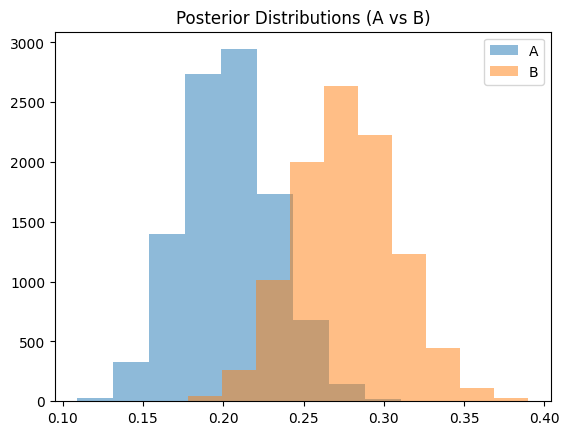

In [126]:
# Plot
plt.hist(samples_A, alpha=0.5, label='A')
plt.hist(samples_B, alpha=0.5, label='B')
plt.legend()
plt.title("Posterior Distributions (A vs B)")
plt.show()

**Interpretation**
* Used Beta-Binomial model

* Computed: P(B>A)

* If:
  * 0.95 → B clearly better
  * ~0.5 → no difference

### **Task 4: Sensitivity & Comparison**

In [127]:
# Change prior
alpha_new, beta_new = 5, 5

alpha_A2 = alpha_new + A_success
beta_A2 = beta_new + (A_total - A_success)

alpha_B2 = alpha_new + B_success
beta_B2 = beta_new + (B_total - B_success)

samples_A2 = np.random.beta(alpha_A2, beta_A2, 10000)
samples_B2 = np.random.beta(alpha_B2, beta_B2, 10000)

prob_B_better2 = np.mean(samples_B2 > samples_A2)

print("After changing prior:")
print("P(B > A):", prob_B_better2)

After changing prior:
P(B > A): 0.9566


In [128]:
# Frequentist comparison (z-test)
pA = A_success / A_total
pB = B_success / B_total

p_pool = (A_success + B_success) / (A_total + B_total)
se = np.sqrt(p_pool * (1 - p_pool) * (1/A_total + 1/B_total))

z = (pB - pA) / se

print("Frequentist Z-score:", z)

Frequentist Z-score: 1.7624204863381403


**Interpretation**

* Changing prior slightly changes results

* Large data -> prior has less influence

* Comparison:
  * Bayesian -> gives probability (intuitive)
  * Frequentist -> gives test statistic (z-score)